# Experiment 2 — MaleficNet SNR / spread-spectrum BER

Rebuilds **Table 5** and **Fig 3** : the signal quality of a
spread-spectrum payload hidden in model parameters, measured **clean** vs.
**after NeuPerm**. NeuPerm reorders the neurons the payload is keyed to, so the
correlator can no longer recover it — SNR (and extraction BER) collapse.

Everything here is rebuilt from the single canonical CSV `../results/exp2_snr.csv`.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)

RESULTS_DIR = Path("../results")

MODEL_RENAME = {
    "densenet121": "DenseNet121", "resnet50": "ResNet50", "resnet101": "ResNet101",
    "vgg11": "VGG11", "vgg16": "VGG16", "mobilenet_v2": "MobileNetV2",
    "mobilenet_v3_small": "MobileNetV3-S",
    "efficientnet_b0": "EfficientNet-B0", "efficientnet_b4": "EfficientNet-B4",
    "llama-3.2-1b": "Llama-3.2-1B", "qwen2.5-1.5b": "Qwen2.5-1.5B",
}

snr = pd.read_csv(RESULTS_DIR / "exp2_snr.csv")
print("modes:", sorted(snr["mode"].unique()))
print("metrics:", sorted(snr["metric"].unique()))
snr.head()

Matplotlib is building the font cache; this may take a moment.


modes: ['maleficnet_fork', 'spread_spectrum_llm']
metrics: ['ber', 'snr']


,mode,model,payload,condition,metric,value,repeat,seed,gamma,error
0,maleficnet_fork,efficientnet_b4,stuxnet,clean,snr,4.874700,NaN,NaN,NaN,NaN
1,maleficnet_fork,efficientnet_b4,stuxnet,after_neuperm,snr,3.564071,NaN,NaN,NaN,NaN
2,maleficnet_fork,efficientnet_b4,destover,clean,snr,4.680069,NaN,NaN,NaN,NaN
3,maleficnet_fork,efficientnet_b4,destover,after_neuperm,snr,3.463045,NaN,NaN,NaN,NaN
4,maleficnet_fork,efficientnet_b4,asprox,clean,snr,4.338640,NaN,NaN,NaN,NaN


## Table 5 — MaleficNet SNR, clean vs. after NeuPerm

`mode == "maleficnet_fork"`, `metric == "snr"`. One row per `(model, payload)`;
`condition` is `clean` or `after_neuperm`. `delta = after_neuperm - clean`;
negative means NeuPerm degraded the hidden signal. Some models have only `clean`
measurements in the shipped CSV (no `after_neuperm`), shown as `NaN` delta.

In [3]:
mf = snr[
    (snr["mode"] == "maleficnet_fork")
    & (snr["metric"] == "snr")
    & (snr["condition"].isin(["clean", "after_neuperm"]))
].copy()
mf["Model"] = mf["model"].map(MODEL_RENAME)

table5 = mf.pivot_table(
    index=["Model", "payload"], columns="condition", values="value", aggfunc="mean"
).reindex(columns=["clean", "after_neuperm"])
table5["delta"] = table5["after_neuperm"] - table5["clean"]
table5

condition                       clean  after_neuperm      delta
Model           payload                                        
DenseNet121     destover     4.617270            NaN        NaN
                stuxnet      5.262961            NaN        NaN
EfficientNet-B0 stuxnet      6.689224       4.097470  -2.591753
EfficientNet-B4 asprox       4.338640       3.214369  -1.124271
                bladabindi   4.944710       4.016049  -0.928660
                destover     4.680069       3.463045  -1.217024
                stuxnet      4.874700       3.564071  -1.310629
MobileNetV2     stuxnet      5.019367       2.958194  -2.061173
                stuxnet_t    0.048618      -2.443960  -2.492577
MobileNetV3-S   stuxnet_t16  5.211029      -4.251249  -9.462279
Qwen2.5-1.5B    asprox       7.350915      -3.562401 -10.913315
                bladabindi   7.569209      -1.838219  -9.407429
                destover     7.664147      -2.598618 -10.262765
                eq.drug      6.821612      -1.575652  -8.397264
                kovter       7.692583      -2.696367 -10.388950
                stuxnet      7.402802      -3.924958 -11.327760
                zeus-bank    7.417150      -3.198137 -10.615287
ResNet101       asprox       6.628930            NaN        NaN
                bladabindi   7.380214            NaN        NaN
                cerber       5.191968            NaN        NaN
                destover     7.005390            NaN        NaN
                eq.drug      5.359013            NaN        NaN
                kovter       5.928011            NaN        NaN
                stuxnet      7.450581            NaN        NaN
ResNet50        asprox       6.048461            NaN        NaN
                bladabindi   6.260534            NaN        NaN
                destover     6.619839            NaN        NaN
                stuxnet      7.094927            NaN        NaN
VGG11           asprox       7.179751            NaN        NaN
                bladabindi   7.667522            NaN        NaN
                cerber       6.921858            NaN        NaN
                destover     7.997200            NaN        NaN
                eq.drug      7.185299            NaN        NaN
                kovter       7.302887            NaN        NaN
                stuxnet      8.049407            NaN        NaN
VGG16           asprox       7.782524     -48.292538 -56.075062
                bladabindi   8.342746     -33.477087 -41.819834
                cerber       6.990325     -23.294273 -30.284598
                destover     8.237315     -22.783818 -31.021133
                eq.drug      6.914026     -19.191703 -26.105729
                kovter       7.844036     -21.989372 -29.833408
                stuxnet      8.199450     -23.956435 -32.155886

### Spread-spectrum extraction BER (self-contained ablation)

`mode == "spread_spectrum_llm"`: our independent spread-spectrum embed/extract on
Llama / Qwen (no external fork, no real malware). Bit-error-rate near 0 means
perfect recovery; NeuPerm drives it toward 0.5 (random).

In [4]:
ber = snr[snr["metric"] == "ber"].copy()
ber["cond"] = ber["condition"].str.replace("ber_", "", regex=False)
ber["Model"] = ber["model"].map(MODEL_RENAME)
(
    ber.groupby(["Model", "cond"])["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

,Model,cond,mean,std,count
0,Llama-3.2-1B,after_neuperm,0.414453,0.193660,5
1,Llama-3.2-1B,clean,0.068359,NaN,1
2,Qwen2.5-1.5B,after_neuperm,0.145703,0.205701,5
3,Qwen2.5-1.5B,clean,0.053711,NaN,1


## Fig 3 — SNR change after NeuPerm (per model / payload)

For every `(model, payload)` pair that has both a `clean` and an `after_neuperm`
SNR, plot the difference `after_neuperm - clean`. Bars point left (negative) when
NeuPerm degraded the payload's recoverable signal.

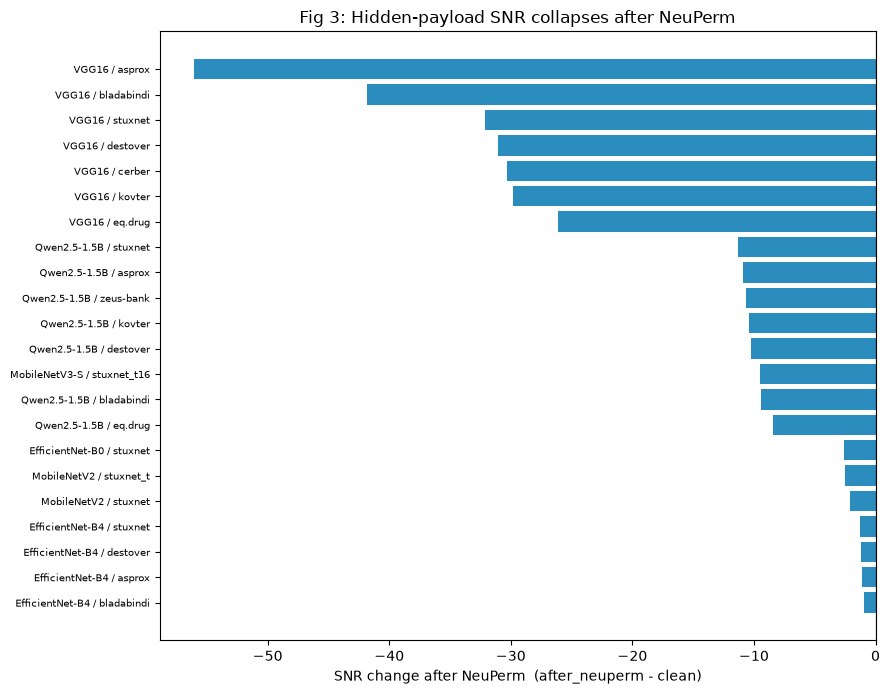

22 model/payload pairs; 22 show reduced SNR after NeuPerm


In [5]:
diff = table5.dropna(subset=["clean", "after_neuperm"]).reset_index()
diff = diff.sort_values("delta").reset_index(drop=True)
labels = [f"{m} / {p}" for m, p in zip(diff["Model"], diff["payload"])]

fig, ax = plt.subplots(figsize=(9, max(3, 0.32 * len(diff))))
colors = np.where(diff["delta"] < 0, "#2b8cbe", "#e34a33")
ax.barh(range(len(diff)), diff["delta"], color=colors)
ax.set_yticks(range(len(diff)))
ax.set_yticklabels(labels, fontsize=7)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("SNR change after NeuPerm  (after_neuperm - clean)")
ax.set_title("Fig 3: Hidden-payload SNR collapses after NeuPerm")
fig.tight_layout()
plt.show()

print(f"{len(diff)} model/payload pairs; "
      f"{(diff['delta'] < 0).sum()} show reduced SNR after NeuPerm")